In [1]:
import torch
import numpy as np
from pathlib import Path
from src.config import DotDict
from src.data_loader import build_dataloaders
from src.models.fusion import MCBFusionNet
from src.utils import r2_score, huber_loss

project_dir = Path.cwd().resolve().parent.parent.parent
data_root = Path("/media/maro/Mom0-0/Datasets/TCGA/pathological")

# 1. Configuration matching your training setup
cfg = DotDict({
    "dataset": {
        "data_root": data_root,
        "features_dir": data_root / "features",
        "tabular_file": project_dir / "data" / "processed" / "stad_rna_selected:21.parquet",
        "target_col": "TMB",
        "patient_id_col": "PATIENT_ID",
        "use_preextracted": True,
        "val_ratio": 0.15,
        "seed": 42,
        "batch_size": 32,
        "image_size": 224,
        "max_patches": 16
    },
    "modalities": {"tabular": True, "image": True},
    "model": {
        "category": "fusion",
        "droprate": 0.0,
        "mcb_out_dim": 512,
        "image_dim": 1024,
        "tabular_model_path": project_dir/"freezed-models/runs/checkpoints/dnn_genetic_paper-epch:50-batch:32-lr:0.01_weights.pth"
    },
    "training":{
        "save_dir": project_dir/"freezed-models/runs/checkpoints"
    }
})

In [2]:
# 2. Load Data and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, val_loader = build_dataloaders(cfg)

# Initialize and load the best fusion weights
model = MCBFusionNet(cfg)
fusion_weights_path = project_dir / "freezed-models/runs/checkpoints/wsi-rna-epch:100-lr:1e-4-dr:0.0-mcb_dim:1024_weights.pth"
model.load_state_dict(torch.load(fusion_weights_path, map_location=device, weights_only=False))
model.to(device)
model.eval()

# LOFO (Leave-One-Feature-Out) evaluation engine

In [3]:
def evaluate_lofo(loader, model_net, missing_modality=None):
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            tabular = torch.tensor(batch["tabular"], dtype=torch.float32).to(device)
            image = torch.tensor(batch["image"], dtype=torch.float32).to(device)
            targets = batch["target"]

            # Apply the LOFO masks
            if missing_modality == "image":
                image = None
            elif missing_modality == "tabular":
                tabular = torch.zeros_like(tabular) # Zero out RNA expression

            preds = model_net(image, tabular)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets)

    return r2_score(all_targets, all_preds)

print("Running Leave-One-Feature-Out (LOFO) Modality Analysis...")
r2_both = evaluate_lofo(val_loader, model, missing_modality=None)
r2_no_image = evaluate_lofo(val_loader, model, missing_modality="image")
r2_no_rna = evaluate_lofo(val_loader, model, missing_modality="tabular")

print("-" * 40)
print(f"Baseline (Both Modalities) R²: {r2_both:.4f}")
print(f"LOFO (RNA Only, No Image) R² : {r2_no_image:.4f}  (Drop of {r2_both - r2_no_image:.4f})")
print(f"LOFO (Image Only, No RNA) R² : {r2_no_rna:.4f}  (Drop of {r2_both - r2_no_rna:.4f})")
print("-" * 40)

Running Leave-One-Feature-Out (LOFO) Modality Analysis...
----------------------------------------
Baseline (Both Modalities) R²: 0.9361
LOFO (RNA Only, No Image) R² : 0.8206  (Drop of 0.1155)
LOFO (Image Only, No RNA) R² : -0.2432  (Drop of 1.1793)
----------------------------------------


# Hybrid Tabular SHAP: Explaining RNA Importance in the Context of a Fixed WSI

## Calc SHAP values

In [4]:
import shap
import matplotlib.pyplot as plt

# 1. Grab a target patient and background dataset
train_loader, _ = build_dataloaders(cfg)
feature_names = train_loader.feature_names

train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))

# Background RNA
X_background_rna = torch.tensor(train_batch["tabular"], dtype=torch.float32).to(device)

# The specific patient we want to explain (Patient 0)
PATIENT_IDX = 0
patient_id = val_batch["patient_ids"][PATIENT_IDX]
patient_rna = torch.tensor(val_batch["tabular"][PATIENT_IDX:PATIENT_IDX+1], dtype=torch.float32).to(device)
patient_image = torch.tensor(val_batch["image"][PATIENT_IDX:PATIENT_IDX+1], dtype=torch.float32).to(device)

print(f"Generating Contextual SHAP for Patient: {patient_id}")

# 2. The Custom Wrapper (Locks the image in place)
class ContextualFusionWrapper(torch.nn.Module):
    def __init__(self, fusion_net, fixed_image):
        super().__init__()
        # Extract the inner PyTorch module from your _TorchBase wrapper
        self.fusion_net = fusion_net._est
        self.fixed_image = fixed_image

    def forward(self, tabular):
        # Dynamically expand the fixed image to match the batch size SHAP is testing
        batch_size = tabular.size(0)
        expanded_image = self.fixed_image.expand(batch_size, -1, -1)

        # Get the prediction (Shape: [Batch])
        out = self.fusion_net(expanded_image, tabular)

        # THE FIX: Add the dimension back so SHAP sees Shape: [Batch, 1]
        return out.unsqueeze(-1)

# Wrap the model
contextual_model = ContextualFusionWrapper(model, patient_image)

# 3. Calculate SHAP
explainer = shap.DeepExplainer(contextual_model, X_background_rna)
shap_values_raw = explainer.shap_values(patient_rna, check_additivity=False)

shap_values = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw
shap_values = np.array(shap_values).reshape(patient_rna.shape) # Flatten to [1, 21]

expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value


Generating Contextual SHAP for Patient: TCGA-BR-4371


/home/maro/final-projects/DSAI_305_XAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/maro/final-projects/DSAI_305_XAI/.venv/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/maro/final-projects/DSAI_305_XAI/.venv/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: MCBLayer
  warnings.warn(f"unrecognized nn.Module: {module_type}")


## Visualize the Contextual SHAP values

Querying MyGene database for readable symbols...


1 input query terms found no hit:	['ENSG00000168078']


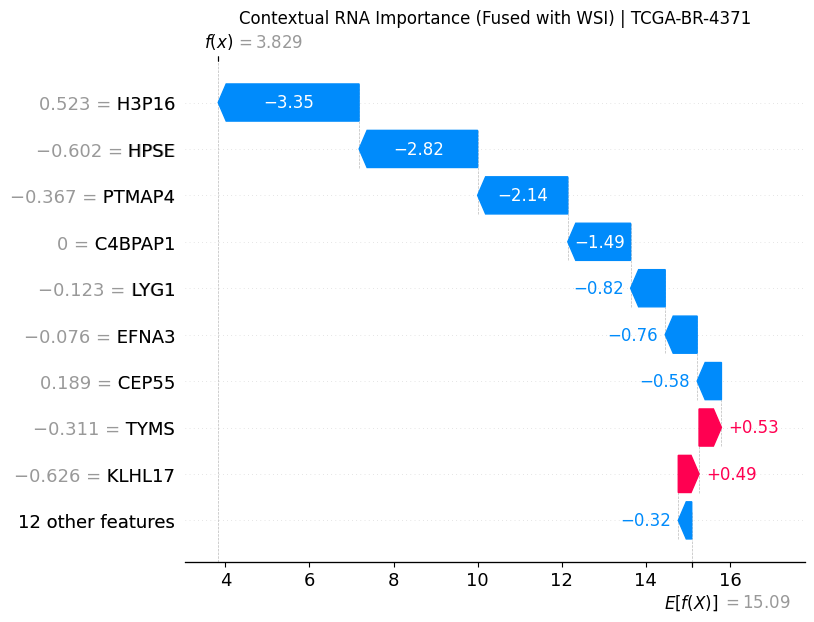

In [5]:
import mygene

# 1. Initialize the query tool
mg = mygene.MyGeneInfo()

# 2. Strip the version numbers from your IDs
# (Your features have suffixes like ".5" or ".14" which confuse the database)
clean_ids = [eid.split('.')[0] for eid in feature_names]

# 3. Query the biological database
print("Querying MyGene database for readable symbols...")
results = mg.querymany(clean_ids, scopes='ensembl.gene', fields='symbol,name', species='human')

# 4. Build a translation dictionary
id_to_symbol = {}
for res in results:
    query = res['query']
    # If the database finds a standard symbol, use it. Otherwise, keep the raw ID.
    symbol = res.get('symbol', query)
    id_to_symbol[query] = symbol

# 5. Translate your feature_names list
readable_feature_names = [id_to_symbol.get(eid.split('.')[0], eid) for eid in feature_names]

# 5. Plot the Contextual Waterfall
local_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=expected_value,
    data=patient_rna.cpu().numpy()[0],
    feature_names= readable_feature_names
)

plt.figure(figsize=(10, 6))
plt.title(f"Contextual RNA Importance (Fused with WSI) | {patient_id}")
shap.plots.waterfall(local_explanation, max_display=10, show=True)